# CS5495 - Explainable AI
# Lecture 2a - Interpretable Linear Models
## Prof. Antoni B. Chan
### Dept. of Computer Science, City University of Hong Kong

# Outline
1. Linear Regression
2. Logistic Regression

In [1]:
# setup
%matplotlib inline
import matplotlib_inline   # setup output image format
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 100  # display larger images
import matplotlib
from numpy import *
from sklearn import *
from scipy import stats
from mpl_toolkits.mplot3d import Axes3D
import pandas as pd

In [2]:
# environment
import sys
print(sys.executable)

# toolbox version
import statsmodels
print(statsmodels.__version__)

/Users/abc/miniforge3/envs/py312ml/bin/python
0.14.5


# Regression
- Supervised learning
  - Input observation $\mathbf{x}$, typically a vector in $\mathbb{R}^d$.
  - Output $y \in \mathbb{R}$, a real number.
- **Goal:** predict output $y$ from input $\mathbf{x}$.
  - i.e., learn the function $y = f(\mathbf{x}) + \epsilon$.
  - $\epsilon$ is noise

In [3]:
linbias = 30
[linX, linY, lincoefs] = datasets.make_regression(n_samples=100, n_features=1, 
                                                  n_informative=1, bias=linbias, noise=10.0, 
                                                  coef=True, random_state=4487)
axbox = [-3, 3, -60, 100]
linfig = plt.figure()
plt.plot(linX, linY, 'b.')
plt.xlabel('feature x')
plt.ylabel('output y')
plt.grid(True); plt.axis(axbox)
plt.close()

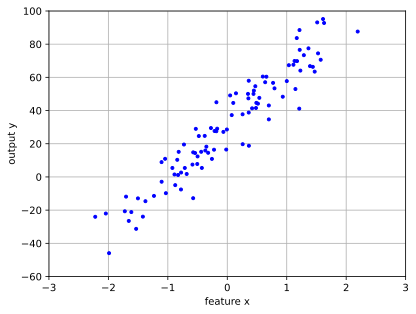

In [4]:
linfig

In [5]:
def load_bikes():
    df = pd.read_csv('bike_sharing_day.csv')
    df['season'] = df['season'].replace([1, 2, 3, 4], ['SPRING', 'SUMMER', 'FALL', 'WINTER'])
    df['weather'] = df['weather'].replace([1, 2, 3], ['GOOD', 'MISTY', 'BAD'])
    df['workday'] = df['workday'].replace([0,1], ['N', 'Y'])
    df['holiday'] = df['holiday'].replace([0,1], ['N', 'Y'])

    return df

In [6]:
bikes_df = load_bikes() 

bikes1dfig = plt.figure(figsize=(8,3))
plt.subplot(1,2,1)
plt.plot(bikes_df['temp'], bikes_df['cnt'], 'b.')
plt.grid(True)
plt.ylabel('cnt')
plt.xlabel('temperature (C)')
plt.subplot(1,2,2)
plt.plot(bikes_df['hum'], bikes_df['cnt'], 'b.')
plt.grid(True)
plt.ylabel('cnt')
plt.xlabel('humidity (%)')
plt.close()

bikes2dfig = plt.figure(figsize=(8,5))
plt.subplot(1,2,1)
plt.scatter(bikes_df['temp'], bikes_df['hum'], c=bikes_df['cnt'], edgecolors='k', cmap='jet')
cbar = plt.colorbar()
cbar.set_label('cnt')
plt.xlabel('temperature (C)')
plt.ylabel('humidity (%)')
plt.grid(True)
plt.close()

ax = bikes2dfig.add_subplot(122, projection='3d')
ax.scatter(bikes_df['temp'], bikes_df['hum'], c=bikes_df['cnt'], edgecolors='k', cmap='jet')
ax.set_xlabel('temperature (C)')
ax.set_ylabel('humidity (%)')
ax.set_zlabel('cnt')

Text(0.5, 0, 'cnt')

# Examples: 
- Predict number of bikes rented from temperature and humidity.
  - Data from Capital-Bikeshare, Washington DC
  - [Fanaee-T, Hadi, and Joao Gama. 2014. “Event Labeling Combining Ensemble Detectors and Background Knowledge.” Progress in Artificial Intelligence 2 (2): 113–27]

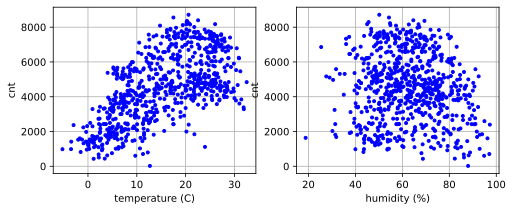

In [7]:
bikes1dfig

- predict from both features

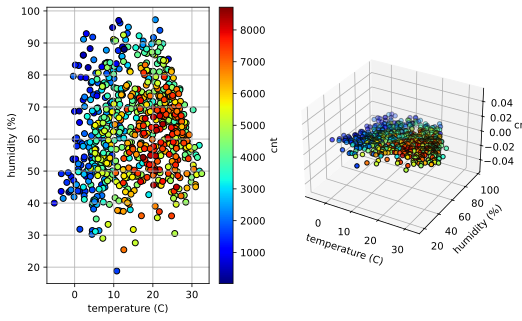

In [8]:
bikes2dfig

# Linear Regression 
- **1-d case:** the linear function of input feature $x$
  - $f(x) = w*x + b$
  - $w$ is the slope, $b$ is the intercept (constant).
- Observe a noisy output of the function:
  - $y = f(x) + \epsilon = w * x + b + \epsilon$
  - $\epsilon$ is assumed Gaussian noise

In [9]:
linfig = plt.figure()
plt.plot(linX, linY, 'b.')
xr = linspace(axbox[0], axbox[1], 100)
plt.plot(xr, lincoefs*xr+linbias, 'r-', label='y = %0.4g x + %0.4g' % (lincoefs, linbias))
plt.xlabel('feature x')
plt.ylabel('output y')
plt.grid(True); plt.axis(axbox)
plt.legend(loc='lower right')
plt.close()

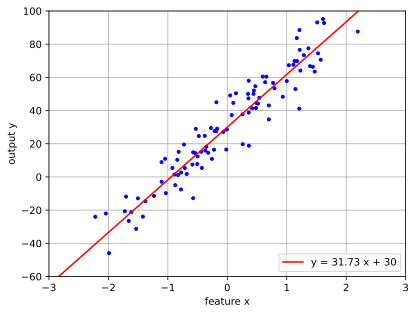

In [10]:
linfig

- **d-dim case**: linear combination (weighted sum) of $d$ input variables $x_1, \cdots, x_d$:
  - $f(\mathbf{x}) = w_0 + w_1 x_1 + w_2 x_2 + \cdots + w_d x_d$
  - Input feature: $x_j$
  - Feature weights: $w_j$
  - Intercept (constant): $w_0$

In [11]:

xr = [linspace(-3,3,100), linspace(-4,4,100)]
xgrid0, xgrid1 = meshgrid(xr[0], xr[1])
allpts = c_[xgrid0.ravel(), xgrid1.ravel()]

w = array([1,2])
b = 20
yout = dot(allpts, w[:,newaxis]) + b
yout = yout.reshape(xgrid0.shape)

lin2dfig = plt.figure(figsize=(8,4))
plt.subplot(121)
plt.imshow(yout, origin='lower', extent=[-3,3,-4,4], cmap='Blues')
cbar.set_label('y')
cbar = plt.colorbar()
CS = plt.contour(xr[0], xr[1], yout, colors='k')
plt.clabel(CS, inline=1, fontsize=10)
plt.xlabel('$x_1$'); plt.ylabel('$x_2$')
plt.title('$y=x_1 + 2x_2 + 20$')
ax = lin2dfig.add_subplot(122, projection='3d')
ax.plot_surface(xgrid0, xgrid1, yout, cmap='Blues')
ax.contour(xr[0], xr[1], yout, zdir='z', offset=0, colors='k')
ax.set_zlim(0,35)
ax.set_zlabel('y')
ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
plt.close()

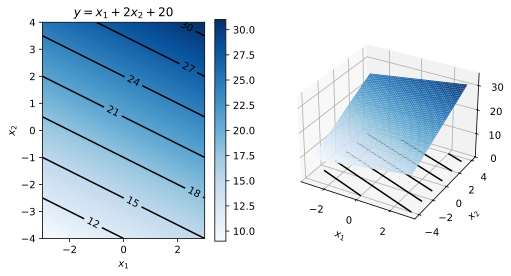

In [12]:
lin2dfig

- Equivalently, using vector notation:
  - $f(\mathbf{x}) = w_0 + \mathbf{w}^T \mathbf{x} = w_0 +\sum_{j=1}^d w_j x_j$
    - $\mathbf{x}\in\mathbb{R}^d$ is the vector of input values.
    - $\mathbf{w}\in\mathbb{R}^d$ are the weights of the linear function, and $w_0$ is the intercept (bias term).

- Observe a noisy output:
  - $y = f(\mathbf{x}) + \epsilon = w_0 + w_1 x_1 + w_2 x_2 + \cdots + w_d x_d + \epsilon$.
  - Gaussian noise: $\epsilon$
- **Predicts the target as a weighted sum of feature inputs.**
  - Linearity makes interpretation easy and modular.
  - Widely used in statistics, medicine, sociology, psychology, and more.

# Key Assumptions
- **Linearity**: Prediction is a linear combination of features.
  - linear effects are easily interpretable.
  - additivity separates the effects.
- **Normality**: Errors are normally distributed.
- **Homoscedasticity**: Constant variance of errors across feature space.
- **Independence**: Each instance is independent, i.e., not repeated measures of the same thing. 
- **Fixed Features**: Features are treated as constants, free of measurement error.
- **No Multicollinearity**: Features should not be strongly correlated.
  - if two features are strongly correlated, then its unclear where the weight should be given. 


# Ordinary Least Squares (OLS)
- The linear function has form $f(\mathbf{x}) = \mathbf{w}^T\mathbf{x} + b$.
- _How to estimate the parameters $(\mathbf{w},b)$ from the data?_
- Fit the parameters by minimizing the squared prediction error on the training set $\{(\mathbf{x}_i,y_i)\}_{i=1}^N$:
  $$\min_{\mathbf{w},b} \sum_{i=1}^N (y_i - f(\mathbf{x}_i))^2 = \min_{\mathbf{w},b} \sum_{i=1}^N (y_i - (\mathbf{w}^T\mathbf{x}_i + b))^2$$

- The bias term $b$ can be absorbed into $\mathbf{w}$ by redefining as follows:
  - $\mathbf{w} \leftarrow \begin{bmatrix}\mathbf{w}\\b\end{bmatrix}$, $\mathbf{x} \leftarrow \begin{bmatrix}\mathbf{x}\\1\end{bmatrix}$

- We can write the minimization problem as:
$$ \min_{\mathbf{w}} ||\mathbf{y}-\mathbf{X}^T\mathbf{w}||^2$$
  - where $\mathbf{X} = [\mathbf{x}_1 \cdots \mathbf{x}_N]$ is the data matrix,
  - and $\mathbf{y} = [y_1, \cdots, y_N]^T$ is vector of outputs.

- Closed-form solution!
  $$\mathbf{w}^* = (\mathbf{X}\mathbf{X}^T)^{-1}\mathbf{X}\mathbf{y}$$
    - Note: $(\mathbf{X}\mathbf{X}^T)^{-1}\mathbf{X}$ is also called the _pseudo-inverse_ of $\mathbf{X}$.

# Model Fit – R-squared
- Prediction: $\hat{y}_i = f(\mathbf{x}_i)$
- **R-squared (Coefficient of Determination)**: Proportion of variance explained by the model.
$$
R^2 = 1 - \frac{SSE}{SST}
$$

  - **SSE (Sum of Squared Errors):** $SSE = \sum_{i=1}^n (y_i - \hat{y}_i)^2$
    - Measures the total squared difference between actual and predicted values.

  - **SST (Total Sum of Squares):** $SST = \sum_{i=1}^n (y_i - \bar{y})^2$
    - Measures the total variance in the observed data.
    - $\bar{y}$ is the mean.

- **Interpretation:**
  - $R^2$ close to 1: model explains most of the variance (SSE=0).
  - $R^2$ close to 0: model explains little of the variance.
    - (SSE=SST, i.e., $\hat{y}_i = \bar{y}$)

- **Adjusted R²:**
  $$
  \bar{R}^2 = 1 - (1 - R^2) \frac{n - 1}{n - p - 1}
  $$
  - Adjusts R² for the number of predictors ($p$) and sample size ($n$).
  - Use adjusted R² when comparing models with different numbers of features.
  - Adjusted $R^2$ penalizes unnecessary predictors.

# Example: Bike Sharing Data
- Bike sharing data from 2011-212 in Washington DC

In [13]:
bikes_df = load_bikes()
bikes_df

,season,holiday,workday,weather,temp,hum,windspeed,cnt_2d_bfr,cnt
0,SPRING,N,Y,GOOD,1.229108,43.7273,16.636703,985,1349
1,SPRING,N,Y,GOOD,1.400000,59.0435,10.739832,801,1562
2,SPRING,N,Y,GOOD,2.666979,43.6957,12.522300,1349,1600
3,SPRING,N,Y,GOOD,1.604356,51.8261,6.000868,1562,1606
4,SPRING,N,Y,MISTY,1.236534,49.8696,11.304642,1600,1510
...,...,...,...,...,...,...,...,...,...
723,SPRING,N,Y,MISTY,3.945849,65.2917,23.458911,1013,2114
724,SPRING,N,Y,MISTY,3.906651,59.0000,10.416557,441,3095
725,SPRING,N,N,MISTY,3.906651,75.2917,8.333661,2114,1341
726,SPRING,N,N,GOOD,4.024151,48.3333,23.500518,3095,1796


- Features:
  - `season` (categorical): season of the year (SPRING, SUMMER, FALL, WINTER)
  - `holiday` (binary): whether it is a US holiday (N, Y)
  - `workday` (binary): whether it is a working day (N, Y)
  - `weather` (categorical): quality of the weather (GOOD, MISTY, BAD)
  - `temp` (numerical): temperature (Celcius)
  - `hum` (numerical): relative humidity (percent)
  - `windspeed` (numerical): wind speed (km/h)
- Target:
  - `cnt` (numerical): number of total rental bikes

# Pre-process the data

In [14]:
import pandas as pd
pd.set_option('display.precision', 3)

# Convert categorical variables to dummy variables (one-hot encoding)
data_dummies = pd.get_dummies(bikes_df, columns=['season', 'holiday', 'workday', 'weather'], dtype=float)

# Define the target and features
# here we drop one item in the categorical to prevent colinearity problems
# Interpretations are relative to the default: Spring, not holiday, workday, good weather
X = data_dummies.drop(columns=['cnt','season_SUMMER', 'holiday_N', 'workday_Y', 'weather_GOOD'])
y = data_dummies['cnt']

# Ensure all columns are numeric
X = X.apply(pd.to_numeric)
y = pd.to_numeric(y)
X

,temp,hum,windspeed,cnt_2d_bfr,season_FALL,season_SPRING,season_WINTER,holiday_Y,workday_N,weather_BAD,weather_MISTY
0,1.229,43.727,16.637,985,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,1.400,59.044,10.740,801,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,2.667,43.696,12.522,1349,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,1.604,51.826,6.001,1562,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,1.237,49.870,11.305,1600,0.0,1.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...
723,3.946,65.292,23.459,1013,0.0,1.0,0.0,0.0,0.0,0.0,1.0
724,3.907,59.000,10.417,441,0.0,1.0,0.0,0.0,0.0,0.0,1.0
725,3.907,75.292,8.334,2114,0.0,1.0,0.0,0.0,1.0,0.0,1.0
726,4.024,48.333,23.501,3095,0.0,1.0,0.0,0.0,1.0,0.0,0.0


# Learn the linear regression model

In [15]:
import statsmodels.api as sm
from sklearn.model_selection import train_test_split

# Add a constant for the intercept
X = sm.add_constant(X)

# extract 2-dim data
X2 = X[['const', 'temp', 'hum']]

# split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X2, y, test_size=0.2, random_state=5495)

# Fit the linear regression model to two dimensions
# OLS = Ordinary Least Squares
model2 = sm.OLS(y_train, X_train).fit()

model2.params

const    3877.975
temp      150.398
hum       -25.657
dtype: float64

In [16]:
model2.rsquared

np.float64(0.44277344987535394)

In [17]:
def plot_linear_2d(model, axbox, X, Y):
    xr = [linspace(axbox[0],axbox[1],100), 
          linspace(axbox[2],axbox[3],100)]
    xgrid0, xgrid1 = meshgrid(xr[0], xr[1])
    allpts = c_[xgrid0.ravel(), xgrid1.ravel()]
    allpts = sm.add_constant(allpts)
    
    ypred = model.predict(allpts).reshape(xgrid0.shape)

    # calculate MSE
    MSE = metrics.mean_squared_error(Y, model.predict(X))

    # make figure
    vmin = Y.min()-1
    vmax = Y.max()+1
    
    # show the 2d function as an image
    plt.imshow(ypred, origin='lower', extent=axbox, aspect='auto', vmin=vmin, vmax=vmax, cmap='jet')
    plt.scatter(X.iloc[:,1], X.iloc[:,2], c=Y, vmin=vmin, vmax=vmax, edgecolors='k', cmap='jet')
    plt.grid(True); plt.axis(axbox)
    plt.title('w=[{:.5f},{:.5f}]; b={:.5f}\nMSE={:.5f}'.format
              (model.params['temp'], model.params['hum'], model.params['const'], MSE))

In [18]:
# make figure
ofig = plt.figure()
plot_linear_2d(model2, [-8,39,0,100], X_train, y_train)
cbar = plt.colorbar()
cbar.set_label('cnt')
plt.xlabel('temperature')
plt.ylabel('humidity')
plt.grid(True)
plt.close()


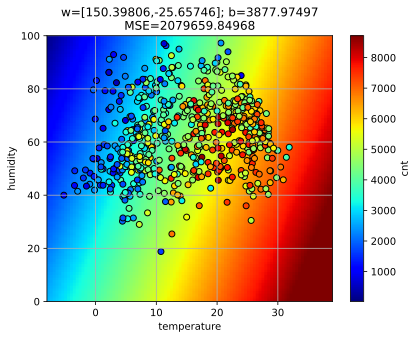

In [19]:
ofig

- interpretation from the linear model parameters:
  - each unit increase (C) in `temp` will increase count: `150.4` ($w_1$)
  - each unit increase (%) in `humidity` will decrease count: `-25.7` ($w_2$)
  - the "starting" count is `3878` ($w_0$), when temp=0 and humid=0

# Examine All Features
  - plots of feature vs. count

In [20]:
bikesfig = plt.figure(figsize=(8,3))
for i,name in enumerate(X.columns):
    plt.subplot(2,6,i+1)
    plt.plot(X[name], y, 'b.')
    plt.grid(True)
    plt.ylim(y.min(), y.max())
    plt.gca().xaxis.set_ticklabels([])
    plt.gca().yaxis.set_ticklabels([])
    plt.title(name)
plt.tight_layout()
plt.close()


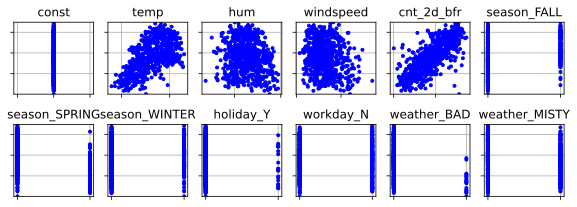

In [21]:
bikesfig

# Fit to all features

In [22]:
# split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=5495)

# Fit the linear regression model to all features
model = sm.OLS(y_train, X_train).fit()
model.rsquared

np.float64(0.7542378263442888)

In [23]:
# prediction on test set
y_pred = model.predict(X_test)
# mean absolute error
metrics.mean_absolute_error(y_test, y_pred)

733.1503514487321

In [24]:
# model weights
model.params

const            3236.797
temp               66.034
hum               -21.455
windspeed         -53.766
cnt_2d_bfr          0.588
season_FALL      -321.366
season_SPRING    -238.557
season_WINTER     261.716
holiday_Y        -398.650
workday_N        -240.859
weather_BAD     -1807.445
weather_MISTY    -361.163
dtype: float64

- Need information about uncertainty and importance!

# Confidence Intervals of Weights

- **Definition:** A confidence interval (CI) gives a range for the estimated weight that is likely to contain the “true” value with a specified probability (e.g., 95%).

- **Interpretation**: if we repeated the experiment 100 times, the 95% interval could contain the “true” weight in 95 out of 100 trials.

- **Calculation:** For each coefficient $\hat{w}_j$, the confidence interval is:
$$\hat{w}_j \pm z^* \cdot SE(\hat{w}_j)$$
  - $\hat{w}_j$: Estimated coefficient
  - $SE(\hat{w}_j)$: Standard error of the estimate
  - $z^*$: Critical value (e.g., 1.96 for 95% confidence)
- **Note:**  The validity of CI depends on assumptions such as linearity, normality, homoscedasticity, independence, and absence of multicollinearity.


# Standard Error of a Weight

- **Definition:** The standard error (SE) of a regression weight measures the variability of the estimate across different samples.

- **Calculation:** For each weight $\hat{w}_j$:
  $$
  SE(\hat{w}_j) = \sqrt{\hat{\sigma}^2 \cdot (X^T X)^{-1}_{jj}}
  $$
  - $\hat{\sigma}^2$: Estimated variance of the residuals (mean squared error)
  - $(X^T X)^{-1}_{jj}$: $j$-th diagonal element of the inverse of the design matrix

- **Interpretation:**  
  - A smaller SE indicates a more precise estimate of the weight.
    - when mean-squared error is small.
    - when $N$ is large.

# Feature Importance of Weight
- feature importance can be measured by the absolute value of the t-statistic:
- t-statistic:
$$
t_j = \frac{\hat{w}_j}{SE(\hat{w}_j)}
$$
- **Interpretation**:
  - importance increases with weight
  - but decreases with uncertainty (SE)

# Hypothesis test on weight

- **Definition:** The t-statistic tests whether a regression coefficient is significantly different from zero.
- **Calculating the p-value:**  
  - The p-value is the probability of observing a t-statistic as extreme as $t_j$ under the null hypothesis (that $w_j = 0$).
  - For a two-sided test: $p = 2 \times (1 - F_{t}( |t_j| ))$
    - $F_{t}$: Cumulative distribution function (CDF) of the t-distribution with $n-d-1$ degrees of freedom
- **Interpretation:**  
  - A small p-value (typically < 0.05) suggests the coefficient is statistically significant (i.e., non-zero), or that the **feature is useful**.


# Example: Weights 

In [25]:
def color_p(value):
  if value < 0.05:
    color = 'green'
  else:
    color = 'red'
  return 'color: %s' % color

def get_summary(model):
    tmp = pd.DataFrame({
      'Weight':  model.params,
      'CI-lower': model.conf_int()[0],
      'CI-upper': model.conf_int()[1],
      'SE':      model.bse,
      '|t|':     model.tvalues.abs(),
      'p-value': model.pvalues,
    })
    tmp=tmp.style.map(color_p, subset=['p-value']).format('{:.3f}')
    return tmp


In [26]:
summary_table = get_summary(model)
summary_table

,Weight,CI-lower,CI-upper,SE,|t|,p-value
const,3236.797,2604.372,3869.222,321.987,10.053,0.000
temp,66.034,47.646,84.423,9.362,7.053,0.000
hum,-21.455,-29.395,-13.516,4.042,5.308,0.000
windspeed,-53.766,-70.697,-36.835,8.620,6.237,0.000
cnt_2d_bfr,0.588,0.533,0.643,0.028,20.952,0.000
season_FALL,-321.366,-577.886,-64.845,130.602,2.461,0.014
season_SPRING,-238.557,-531.583,54.470,149.189,1.599,0.110
season_WINTER,261.716,7.566,515.865,129.395,2.023,0.044
holiday_Y,-398.650,-883.369,86.068,246.785,1.615,0.107
workday_N,-240.859,-416.878,-64.840,89.616,2.688,0.007


- most weights are statistically significiant ($p<0.05$), i.e., non-zero.
- `season_SPRING` and `holiday_Y` are not statistically significant (not important).

# Interpretation of Weights
$$
f(\mathbf{x})= w_0 + w_1 x_{1} + \ldots + w_p x_{p}
$$

- **Numerical Feature**: Increase by one unit changes outcome value by its weight.
- **Binary Feature**: Change from reference to other category changes outcome value by its weight.
- **Categorical Feature**: Use one-hot encoding; each category (except reference) adds outcome value by its weight.
- **Intercept** ($w_0$): Prediction when all features are at reference (all zero).
- **Caveats**:
  - the change is with respect to other features remaining the same.
  - ignores joint distribution of features (e.g., humidity is usually higher when it's hot, and lower when it's cold)

# Example Interpretations
- **Numerical feature** (`temp`): temperature increase of 1 degree Celsius increases the predicted  count by `66.0` (when all other features remain fixed).
- **Binary feature** (`workday_N`): when it is not a workday, the predicted count decreases by `240.9`.
- **Categorical feature** (`weather`): the predicted count is `1807.4` lower when weather is bad, compared to when it is a good (the reference). When the weather is misty, the predicted number is `361.2` lower compared to good weather.
- **Intercept** (`const`): the predicted count is `3237` during the reference condition (all numerical features are zero, WINTER season, not a holiday, a working day, good weather)




In [27]:
summary_table

,Weight,CI-lower,CI-upper,SE,|t|,p-value
const,3236.797,2604.372,3869.222,321.987,10.053,0.000
temp,66.034,47.646,84.423,9.362,7.053,0.000
hum,-21.455,-29.395,-13.516,4.042,5.308,0.000
windspeed,-53.766,-70.697,-36.835,8.620,6.237,0.000
cnt_2d_bfr,0.588,0.533,0.643,0.028,20.952,0.000
season_FALL,-321.366,-577.886,-64.845,130.602,2.461,0.014
season_SPRING,-238.557,-531.583,54.470,149.189,1.599,0.110
season_WINTER,261.716,7.566,515.865,129.395,2.023,0.044
holiday_Y,-398.650,-883.369,86.068,246.785,1.615,0.107
workday_N,-240.859,-416.878,-64.840,89.616,2.688,0.007


# Example: Weight plot
- show weights and confidence intervals for each feature.

In [28]:
def plot_weights(model, showconst=True):
    # Create a DataFrame for plotting weights and CI
    plot_df = pd.DataFrame({
        'coef': model.params,
        'lower': model.conf_int()[0],
        'upper': model.conf_int()[1]
    })

    if (not showconst):
        plot_df = plot_df.drop(index=['const'])
    
    # Plotting the weight plot with 95% confidence intervals
    fig1 = plt.figure(figsize=(8, 4))
    plt.errorbar(plot_df['coef'],plot_df.index,
                 xerr=[plot_df['coef'] - plot_df['lower'], plot_df['upper'] - plot_df['coef']],
                 fmt='o', color='blue', ecolor='gray', capsize=5)
    plt.axvline(0, color='red', linestyle='--')
    plt.title('Weights with 95% Confidence Intervals')
    plt.grid(True); plt.tight_layout()
    plt.close()
    return fig1

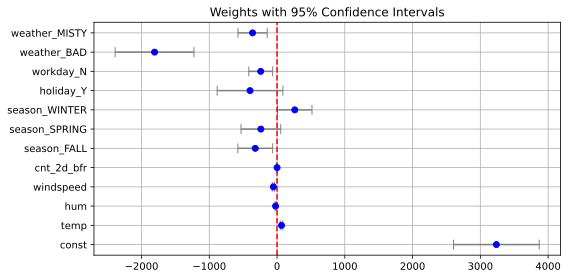

In [29]:
plot_weights(model)

- `weather_BAD` has strong negative weight, `temp` has small weight
- hard to compare weights: features are measured on different scales (e.g., temperature vs. binary feature) 


# Effect Plot in Linear Regression

- **Definition:** The effect plot visualizes the distribution of each feature’s contribution to the model’s prediction across all data points.
- **How to Calculate Effects:**  
  - For each feature and each instance, compute: $\text{Effect}_{ij} = x_{ij} \cdot \hat{w}_j$
    - $x_{ij}$: Value of feature $j$ for instance $i$
    - $\hat{w}_j$: Estimated weight for feature $j$
- **Visualization:** 
  - For each feature, plot a boxplot of its effects across all samples.
- **Interpretation:** 
  - Shows which features have the largest and most variable impact on predictions.
  - Helps explain individual predictions by comparing an instance’s effects to the overall distribution.


# Example: Effects Plot

In [30]:
def calculate_effects(model, X):
    # Extract coefficients
    weights = model.params
    
    # Calculate effects: effect = feature value × weight
    effects = X.mul(weights, axis=1)
    return effects

def plot_effects(effects, selsample=None, testeffects=None, showconst=True):
    # selsample will select a sample to plot from effects, or from testeffects if provided

    if (not showconst):
        # Drop the intercept for plotting effects
        effects_new = effects.drop(columns='const')
        if testeffects is not None:
            testeffects_new = testeffects.drop(columns='const')
    else:
        effects_new = effects
        if testeffects is not None:
            testeffects_new = testeffects

    # Create boxplots for feature effects
    myfig = plt.figure(figsize=(8, 4))
    effects_new.boxplot(vert=False)

    if (selsample is not None) or (testeffects is not None):
        # Choose the instance to highlight from test data
        if testeffects is not None:
            highlight_effects = testeffects_new.iloc[selsample]
        else:
            # or training data
            highlight_effects = effects_new.iloc[selsample]

        # Overlay the highlighted instance's effects as red crosses
        for i, feature in enumerate(effects_new.columns):
            plt.plot(highlight_effects[feature], i + 1, 'rx', markersize=10, label='Highlighted Instance' if i == 0 else "")

    plt.title('Effect Plot: Distribution of Feature Effects Across Data')
    plt.ylabel('Effect Value')
    plt.tight_layout()
    plt.show()
    plt.close()

- The box shows the interquartile range (middle 50%), the line is the median, and whiskers show the spread, and dots show the outliers.
- largest positive effect is from `temp` and `cnt_2d_bfr`. 
- largest negative effect is from `windspeed`, `hum`, and `weather_BAD`.

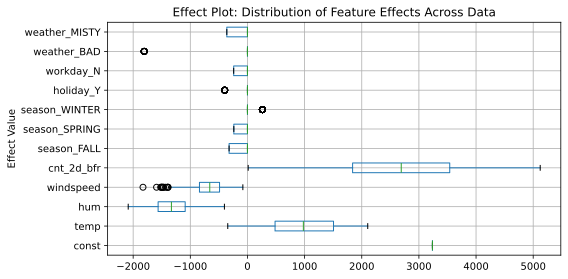

In [31]:
effects = calculate_effects(model, X_train)
plot_effects(effects)

# Example: Effects plot for a test sample

- the 1st test sample features:

In [32]:
X_test.iloc[0]

const               1.000
temp                7.353
hum                51.917
windspeed          12.667
cnt_2d_bfr       3974.000
season_FALL         0.000
season_SPRING       0.000
season_WINTER       1.000
holiday_Y           0.000
workday_N           1.000
weather_BAD         0.000
weather_MISTY       0.000
Name: 305, dtype: float64

- the model prediction

In [33]:
model.predict(X_test.iloc[0])

None    4284.47
dtype: float64

- view the effects for this sample 

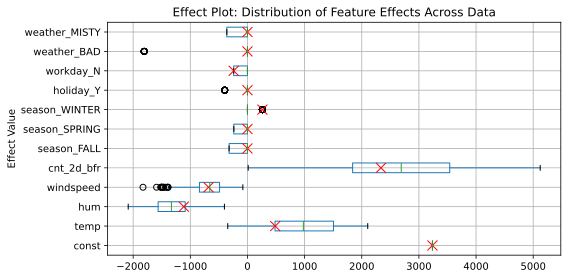

In [34]:
testeffects = calculate_effects(model, X_test)
plot_effects(effects, selsample=0, testeffects=testeffects)

- For this sample, `windspeed` and `hum` have a large negative effects. `temp` has a positive effect.

# Reference values
- For numerical values, the reference for linear regression is when the input is all zeros. 
- In the previous example, the reference is `temp=0`, and when `temp` is close to zero there is little effect on the prediction.
- Interpretability could be improved by scaling numerical data so that the reference is the average value.

# Z-scoring
  - Transforms each numerical feature to have mean 0 and standard deviation 1:
    $$
    z_j = \frac{x_j - \mu_j}{\sigma_j}
    $$
    - $x_j$: Original feature value
    - $\mu_j$: Mean of feature $j$
    - $\sigma_j$: Standard deviation of feature $j$
- **Why Standardize?**
  - Puts all numerical features on the same scale, removing the influence of units and magnitude.
  - Makes the weights directly comparable across features.
- **Interpretation:**
  - After z-scoring, each coefficient $w_j$ represents the expected change in the target variable for a _one standard deviation increase_ in feature $j$, holding other features constant.
  - Helps identify which features have the strongest effect on the prediction, regardless of their original units.

# Example: Using Z-scoring

In [35]:
def make_scaler_df(featnames, scaler):
    df = pd.DataFrame({
     'mean': scaler.mean_,
     'std' : sqrt(scaler.var_),
      }, index=featnames )
    return df

In [36]:
from sklearn.preprocessing import StandardScaler

# make a copy
Xzs_train = X_train.copy(deep=True)
Xzs_test  = X_test.copy(deep=True)

# list of numerical features
numfeats = ['windspeed', 'hum', 'temp']

# scale based on the training set statistics
scaler = StandardScaler()
Xzs_train[numfeats] = scaler.fit_transform(Xzs_train[numfeats])
Xzs_test[numfeats]  = scaler.transform(Xzs_test[numfeats])

make_scaler_df(numfeats, scaler)

,mean,std
windspeed,12.867,5.126
hum,62.283,14.153
temp,14.961,8.605


In [37]:
# Fit the linear regression model to all features
modelzs = sm.OLS(y_train, Xzs_train).fit()
summary_tablezs = get_summary(modelzs)
summary_tablezs

,Weight,CI-lower,CI-upper,SE,|t|,p-value
const,2196.604,1883.525,2509.683,159.398,13.781,0.000
temp,568.223,409.988,726.458,80.562,7.053,0.000
hum,-303.656,-416.017,-191.294,57.207,5.308,0.000
windspeed,-275.582,-362.365,-188.799,44.184,6.237,0.000
cnt_2d_bfr,0.588,0.533,0.643,0.028,20.952,0.000
season_FALL,-321.366,-577.886,-64.845,130.602,2.461,0.014
season_SPRING,-238.557,-531.583,54.470,149.189,1.599,0.110
season_WINTER,261.716,7.566,515.865,129.395,2.023,0.044
holiday_Y,-398.650,-883.369,86.068,246.785,1.615,0.107
workday_N,-240.859,-416.878,-64.840,89.616,2.688,0.007


- If `temp` increases by *one standard deviation* (8.6C), then predicted count increases by `568.2`.
- If `hum` increases by *one standard deviation* (14%), then predicted count decreases by `303.7`.
- If `windspeed` increases by *one standard deviation* (5.1 km/h), then predicted count decreases by `279.3`.
- `const`: on summer, non-holiday, working day with good weather, and average temperature (15.0C), humidity (62.3%), and windspeed (12.9 km/h), the predicted count is `2213.7`.

In [38]:
modelzs.rsquared

np.float64(0.7542378263442887)

In [39]:
# prediction on test set
y_pred = modelzs.predict(Xzs_test)
# mean absolute error
metrics.mean_absolute_error(y_test, y_pred)

733.1503514486857

# Example: effects plot with Z-scoring
- now using Z-scoring

In [40]:
Xzs_test.iloc[0]

const               1.000
temp               -0.884
hum                -0.732
windspeed          -0.039
cnt_2d_bfr       3974.000
season_FALL         0.000
season_SPRING       0.000
season_WINTER       1.000
holiday_Y           0.000
workday_N           1.000
weather_BAD         0.000
weather_MISTY       0.000
Name: 305, dtype: float64

In [41]:
modelzs.predict(Xzs_test.iloc[0])

None    4284.47
dtype: float64

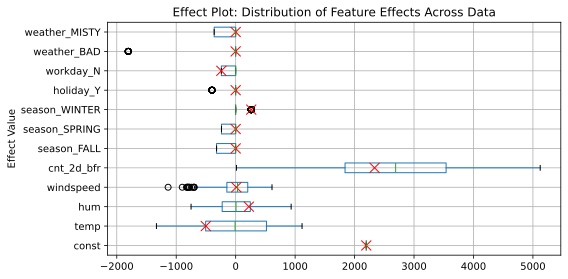

In [42]:
effectszs = calculate_effects(modelzs, Xzs_train)
testeffectszs = calculate_effects(modelzs, Xzs_test)
plot_effects(effectszs, selsample=0, testeffects=testeffectszs)

- relatively lower `hum` (compared to mean), leads to increased prediction.
- relatively lower `temp` (compared to mean), leads to decreased the prediction.

# Other Encoding of Categoricals

- **Treatment Coding (Reference Coding)**
  - One category is chosen as the reference.
  - Other categories are compared against the reference.
  - Example: For a feature with categories A, B, C:
$$\begin{pmatrix}A\\A\\B\\C\end{pmatrix} \Rightarrow \begin{pmatrix}1 & 0 & 0 \\ 1 & 0 & 0 \\ 1 & 1 & 0 \\ 1&0&1\end{pmatrix}$$
    - A is the reference (intercept).
    - Encode B and C as binary columns.
  - Interpretation: Coefficients represent the difference from the reference category.
- **Effect Coding**
  - Compares each category to the overall mean (intercept).
  - Reference category gets a coefficient that balances the others.
$$\begin{pmatrix}A\\A\\B\\C\end{pmatrix} \Rightarrow \begin{pmatrix}1 & -1 & -1 \\ 1 & -1 & -1 \\ 1 & 1  & 0 \\ 1&0&1\end{pmatrix}$$
  - Useful for balanced interpretation across categories.

- **Dummy Coding (one-hot)**
  - Each category gets its own binary column.
$$\begin{pmatrix}A\\A\\B\\C\end{pmatrix} \Rightarrow \begin{pmatrix}1 & 0 & 0 \\ 1 & 0 & 0 \\ 0 & 1 & 0 \\ 0&0&1\end{pmatrix}$$
  - One column is dropped to avoid multicollinearity.
  - Interpretation: Coefficients represent the mean value for each category.
- **Best Practices:**
  - Always drop one column to avoid perfect multicollinearity.
  - Choose encoding based on interpretability needs.

# Output transformation
- if the dynamic range of the output is large, then the homoscedasticity assumption might not hold.
- E.g., the output is the house price: \\$10,000 to \\$10,000,000
  - suppose the average prediction error is \\$50,000, then we assume the same error for the \\$40,000 house and the \\$10,000,000 house!
- Solution: apply a transformation:
  - $y \Rightarrow \log(y)$

# Summary of Linear Regression
- **Strengths**
  - Transparent, easy to interpret.
  - Well-established, widely used.
  - Solid statistical theory and software support.
  - Extensions available (GLM, GAM, etc.).
  - Selective explanations - based on the effects

- **Limitations**
  - Only models linear relationships, i.e., weighted sum.
  - Nonlinearities and interactions must be explicitly added (hand-crafted).
  - Can perform poorly if relationships are complex.
  - Interpretation can be unintuitive with correlated features.
  - Contrastive explanations: to the "zero" instance. 
  - if using z-scoring, then contrastive to the "mean" instance. 